In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
import warnings
import os

In [3]:
sheet_id = "1LIET0bMfFwF814IHDB2Fw1RPD0KOyUQx"
sheet_name = "case_study1"

url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
df1 = pd.read_csv(url)

In [4]:
sheet_id = "1BUMvIet7UKfxcC0GOE7COO_gVZA5Vwip"
sheet_name = "case_study2"

url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
df2 = pd.read_csv(url)

In [5]:
df1.head()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,...,0,0,1,0,4,1,4,0,72,18
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,...,0,1,0,0,0,0,1,0,7,7
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,...,0,6,1,0,0,2,6,0,47,2
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,...,0,0,0,0,0,0,1,1,5,5
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,...,0,0,0,0,0,3,0,2,131,32


In [6]:
df2.head()

,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,549,35,15,11,29,29,0,0,0,...,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,47,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,302,11,3,9,25,25,1,9,8,...,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,-99999,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,583,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1


In [7]:
df1 = df1[df1['Age_Oldest_TL'] != -99999]
for col in df2.columns:
    if (df2[col] == -99999).sum() > 10000:
        df2.drop(columns=col, inplace=True)
df2 = df2[(df2 != -99999).all(axis=1)]

In [8]:
df = pd.merge(df1, df2, on='PROSPECTID', how='inner')


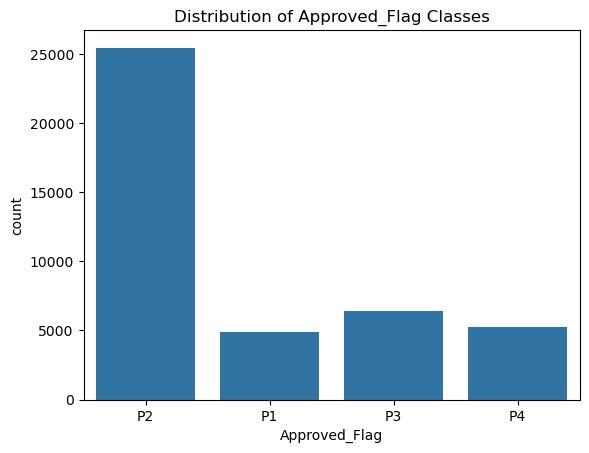

In [10]:
import seaborn as sns
sns.countplot(x='Approved_Flag', data=df)
plt.title('Distribution of Approved_Flag Classes')
plt.show()


In [11]:
df.columns

Index(['PROSPECTID', 'Total_TL', 'Tot_Closed_TL', 'Tot_Active_TL',
       'Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M',
       'pct_tl_closed_L6M', 'pct_active_tl', 'pct_closed_tl',
       'Total_TL_opened_L12M', 'Tot_TL_closed_L12M', 'pct_tl_open_L12M',
       'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL',
       'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Secured_TL',
       'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL',
       'time_since_recent_payment', 'num_times_delinquent',
       'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts',
       'num_deliq_6_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd',
       'num_std', 'num_std_6mts', 'num_std_12mts', 'num_sub', 'num_sub_6mts',
       'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_dbt_12mts', 'num_lss',
       'num_lss_6mts', 'num_lss_12mts', 'recent_level_of_deliq', 'tot_enq',
       'CC_enq', 'CC_enq_L6m', 'CC_enq_L12m', 'PL_enq', 'PL_enq_L6m',
       'PL_enq_L12

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42064 entries, 0 to 42063
Data columns (total 79 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PROSPECTID                  42064 non-null  int64  
 1   Total_TL                    42064 non-null  int64  
 2   Tot_Closed_TL               42064 non-null  int64  
 3   Tot_Active_TL               42064 non-null  int64  
 4   Total_TL_opened_L6M         42064 non-null  int64  
 5   Tot_TL_closed_L6M           42064 non-null  int64  
 6   pct_tl_open_L6M             42064 non-null  float64
 7   pct_tl_closed_L6M           42064 non-null  float64
 8   pct_active_tl               42064 non-null  float64
 9   pct_closed_tl               42064 non-null  float64
 10  Total_TL_opened_L12M        42064 non-null  int64  
 11  Tot_TL_closed_L12M          42064 non-null  int64  
 12  pct_tl_open_L12M            42064 non-null  float64
 13  pct_tl_closed_L12M          420

In [13]:
(df == -99999).sum()


PROSPECTID             0
Total_TL               0
Tot_Closed_TL          0
Tot_Active_TL          0
Total_TL_opened_L6M    0
                      ..
GL_Flag                0
last_prod_enq2         0
first_prod_enq2        0
Credit_Score           0
Approved_Flag          0
Length: 79, dtype: int64

In [14]:
df['Age_Oldest_TL'].unique()  # replace with any suspect column


array([ 72,   7,  47, 131, 150,  36,  16,  64,  49,  38,   9, 138,   8,
        92,  40,  51,  59,  37, 159,  10,  20,   4,  26,  19,  41,  73,
        45,  32,  33,  48,  18,  60,  14,  83,  44,  24,  42,  11,  39,
        12,  27,  70,   6,  76, 115,  66,  46,  93,  56,  61, 113,  67,
         5, 191,  65,  43,  29, 193,  63,  58,  30,  23,  53, 145,  31,
        77, 104,  87,  15,  62,  21,  69,  97,  34,  28,  74, 137,  86,
        13, 124, 129,  50,  17,  96, 154, 148, 128,  94, 107, 135,  22,
        81,  68,  78, 130,  71,  35,  89, 123, 213,  88,  91,  52, 110,
       174, 111,  90,  57, 183, 108,  54,  79, 166,  55, 160, 146,  84,
       167,  75,  80, 116, 100, 197, 181, 155, 126,  25, 168,  95, 149,
       136, 172, 134, 133, 179, 184, 144,  98, 177, 117, 176,   3, 114,
       186, 109, 164, 141,  82, 132, 125, 142,   2, 230,   1,  85, 106,
       153, 127, 169, 165, 182, 187, 178, 101, 170, 190, 157, 205, 140,
       121, 267, 198, 105, 102, 103, 158, 192, 151, 143, 188, 11

In [15]:
print(df.dtypes)


PROSPECTID              int64
Total_TL                int64
Tot_Closed_TL           int64
Tot_Active_TL           int64
Total_TL_opened_L6M     int64
                        ...  
GL_Flag                 int64
last_prod_enq2         object
first_prod_enq2        object
Credit_Score            int64
Approved_Flag          object
Length: 79, dtype: object


In [16]:
(df == -99999).sum().sort_values(ascending=False)


PROSPECTID       0
CC_enq_L12m      0
enq_L3m          0
enq_L6m          0
enq_L12m         0
                ..
Age_Newest_TL    0
Age_Oldest_TL    0
Other_TL         0
Unsecured_TL     0
Approved_Flag    0
Length: 79, dtype: int64

In [17]:
df[df.apply(lambda row: (row == -99999).any(), axis=1)]


,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag


In [20]:
import numpy as np
df.replace(-99999, np.nan, inplace=True)


In [21]:
df.isnull().sum() 

PROSPECTID             0
Total_TL               0
Tot_Closed_TL          0
Tot_Active_TL          0
Total_TL_opened_L6M    0
                      ..
GL_Flag                0
last_prod_enq2         0
first_prod_enq2        0
Credit_Score           0
Approved_Flag          0
Length: 79, dtype: int64

In [22]:
df.head()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,...,0.0,0.0,0.000,0.0,1,0,PL,PL,696,P2
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,...,0.0,0.0,0.000,0.0,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,...,0.0,0.0,0.000,0.0,1,0,ConsumerLoan,others,693,P2
3,5,3,2,1,0,0,0.000,0.0,0.333,0.667,...,0.0,0.0,0.000,0.0,0,0,AL,AL,753,P1
4,6,6,5,1,0,0,0.000,0.0,0.167,0.833,...,1.0,0.0,0.429,0.0,1,0,ConsumerLoan,PL,668,P3


In [24]:
# check how many columns are categorical
for i in df.columns:
    if df[i].dtype == 'object':
        print(i)
   

MARITALSTATUS
EDUCATION
GENDER
last_prod_enq2
first_prod_enq2
Approved_Flag


In [25]:
cat_cols = ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2', 'Approved_Flag']
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.upper()

In [26]:
df['Approved_Flag'] = df['Approved_Flag'].map({'P1': 0, 'P2': 1, 'P3': 2, 'P4': 3})


In [27]:
education_map = {
    'SSC': 1, '12TH': 2, 'GRADUATE': 3, 'UNDER GRADUATE': 3,
    'POST-GRADUATE': 4, 'OTHERS': 1, 'PROFESSIONAL': 3
}
df['EDUCATION'] = df['EDUCATION'].map(education_map).astype(int)

In [28]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['PROSPECTID', 'Approved_Flag'])

In [29]:
vif_data = df[numeric_cols]
def calculate_vif(df_vif):
    vif = pd.DataFrame()
    vif["Feature"] = df_vif.columns
    vif["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]
    return vif[vif['VIF'] <= 6]["Feature"].tolist()

selected_numeric = calculate_vif(vif_data)


C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [30]:
# Chi-square test for categorial
cat_cols = ['MARITALSTATUS', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']
for col in cat_cols:
    chi2, p, _, _ = chi2_contingency(pd.crosstab(df[col], df['Approved_Flag']))
    if p > 0.05:
        cat_cols.remove(col)

In [31]:
# Encode binary categorical features
df['MARITALSTATUS'] = df['MARITALSTATUS'].map({'MARRIED': 1, 'SINGLE': 0})
df['GENDER'] = df['GENDER'].map({'M': 1, 'F': 0})

In [41]:
df = pd.get_dummies(df, columns=['last_prod_enq2', 'first_prod_enq2'])

KeyError: "None of [Index(['last_prod_enq2', 'first_prod_enq2'], dtype='object')] are in the [columns]"

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42064 entries, 0 to 42063
Data columns (total 89 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PROSPECTID                    42064 non-null  int64  
 1   Total_TL                      42064 non-null  int64  
 2   Tot_Closed_TL                 42064 non-null  int64  
 3   Tot_Active_TL                 42064 non-null  int64  
 4   Total_TL_opened_L6M           42064 non-null  int64  
 5   Tot_TL_closed_L6M             42064 non-null  int64  
 6   pct_tl_open_L6M               42064 non-null  float64
 7   pct_tl_closed_L6M             42064 non-null  float64
 8   pct_active_tl                 42064 non-null  float64
 9   pct_closed_tl                 42064 non-null  float64
 10  Total_TL_opened_L12M          42064 non-null  int64  
 11  Tot_TL_closed_L12M            42064 non-null  int64  
 12  pct_tl_open_L12M              42064 non-null  float64
 13  p

In [36]:
df['EDUCATION'].value_counts()

KeyError: 'EDUCATION'

In [39]:
# Step 1: Load only PROSPECTID and EDUCATION from case_study1
edu_col = pd.read_excel("/mnt/data/case_study2.xlsx", usecols=['PROSPECTID', 'EDUCATION'])

# Step 2: Merge it back with your current merged dataframe
df = df.merge(edu_col, on='PROSPECTID', how='left')


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/case_study2.xlsx'